# 12.2.2 混合假设与空间合作

## 学习目标与先修知识

比较相同收益规则在平均混合（homogeneous mixing）与局部邻域中的差异。

先修：12.2.1 收益矩阵（payoff matrix）与复制动态（replicator dynamics）；11.1 邻接与局部接触。

## 具体问题

两组细胞都各有一半类型0，却分别成团和交错排列。若只与相邻细胞相遇，它们取得的收益是否由全局频率唯一决定？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先排列八个类型0和八个类型1，手数端点相遇的对方类型。

In [2]:
cluster=[0]*8+[1]*8; alternate=[0,1]*8
print('两种排列的类型0比例：',cluster.count(0)/16,alternate.count(0)/16)

两种排列的类型0比例： 0.5 0.5


## 模型假设

16 个个体排成周期环，邻居仅左右各一位；每人收益取两次相遇的平均。两组使用同一收益表，尚未定义繁殖或模仿更新，因此只比较相遇收益，不宣称合作会在下一代增加。

## 数学解释与推导

充分混合时类型0的平均收益是 $f_0=pM_{00}+(1-p)M_{01}$。局部接触时第 $i$ 人收益为 $g_i=\tfrac12[M_{s_i,s_{i-1}}+M_{s_i,s_{i+1}}]$。相同 $p$ 不能决定每位个体邻居类型，更不能决定 $g_i$；空间相关性是充分混合近似遗漏的信息。收益差若要变成下一代频率，还要指定选择、更新时序和随机抽样。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def payoff_and_replicator(matrix, p):
    """Type 0 frequency p, type 1 frequency 1-p."""
    f0 = p * matrix[0][0] + (1 - p) * matrix[0][1]
    f1 = p * matrix[1][0] + (1 - p) * matrix[1][1]
    mean = p * f0 + (1 - p) * f1
    return [f0, f1, mean, p * (f0 - mean)]


def local_payoffs(state, matrix, boundary):
    """Each individual meets its existing left/right neighbors once."""
    n = len(state)
    result = []
    for i, strategy in enumerate(state):
        neighbors = [(i - 1) % n, (i + 1) % n] if boundary == 'periodic' else [
            j for j in (i - 1, i + 1) if 0 <= j < n]
        result.append(sum(matrix[strategy][state[j]] for j in neighbors) / len(neighbors))
    return result

## 对照实验

在成团和交错状态（state）计算逐个体收益，和充分混合的类型平均收益并列。

成团 类型0均值 2.625 类型1均值 1.375
交错 类型0均值 0.0 类型1均值 4.0
充分混合两类预期收益： [1.5, 2.5]


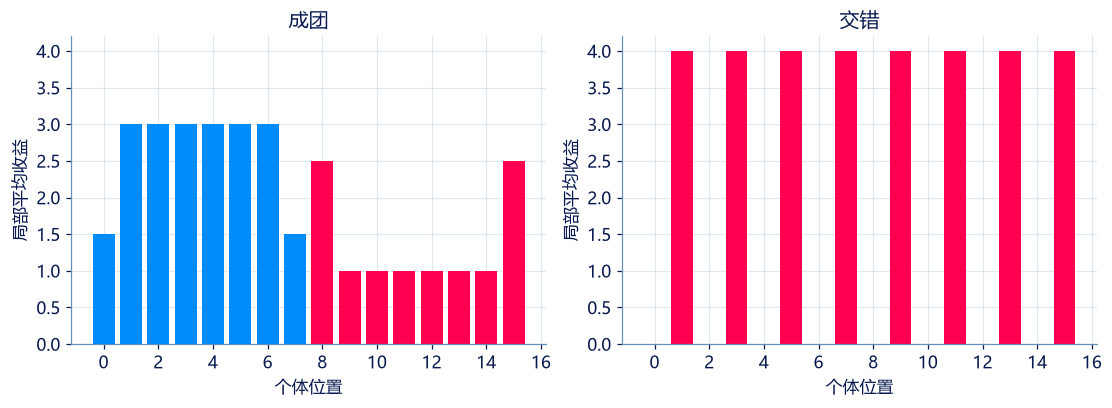

In [4]:
M=[[3.,0.],[4.,1.]]
patterns={'成团':cluster,'交错':alternate}
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,(name,state) in zip(axes,patterns.items()):
    gain=local_payoffs(state,M,'periodic')
    ax.bar(range(16),gain,color=[BLUE if bit==0 else PINK for bit in state])
    ax.set(xlabel='个体位置',ylabel='局部平均收益',title=name,ylim=(0,4.2))
    print(name,'类型0均值',np.mean([g for bit,g in zip(state,gain) if bit==0]),
          '类型1均值',np.mean([g for bit,g in zip(state,gain) if bit==1]))
print('充分混合两类预期收益：',payoff_and_replicator(M,.5)[:2])
plt.show()

## 结果解释

成团让多数个体遇到同型邻居，交错则都遇到异型邻居；全局 p 相同而局部收益不同。这不是演化终点结论，因为没有给出收益到后代状态的映射。

### 独立核对

独立核对四格小例每位邻居收益，并确认固定边界（fixed boundary）只减少端点接触次数。

In [5]:
np.testing.assert_allclose(local_payoffs([0,0,1,1],M,'periodic'),[1.5,1.5,2.5,2.5])
np.testing.assert_allclose(local_payoffs([0,0,1,1],M,'fixed'),[3.,1.5,2.5,1.])
assert sum(cluster)==sum(alternate)==8
print('邻居收益与频率一致、排列不同的反例通过。')

邻居收益与频率一致、排列不同的反例通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算局部相遇收益

一维策略排列中，每个个体与现存左右邻居各相遇一次，返回该个体收益的邻居平均。periodic 首尾相连；fixed 端点只有一位邻居。matrix 行为本体策略，列为邻居策略。

**函数与代码模板**

```python
def solve(
    state: list[int],
    matrix: list[list[float]],
    boundary: str,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 长度至少3、取0或1的策略排列。 | 类别 |
| `matrix` | `list[list[float]]` | 2×2 行对列收益。 | 收益单位 |
| `boundary` | `str` | periodic 或 fixed。 | 类别 |

**返回值**

直接返回 payoffs（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `payoffs` | `list[float]` | 各位置局部平均收益。 | 收益单位 |

**计算规则**

先找到真实邻居，再逐项取 M[state[i]][state[j]] 并除以本节点邻居数；不在此题实施选择更新。

**约束与边界**

- 只使用题定的有限状态（state）、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 长度至少3、取0或1的策略排列。 | [0, 0, 1, 1] | 类别 |
| matrix | 2×2 行对列收益。 | [[3.0, 0.0], [4.0, 1.0]] | 收益单位 |
| boundary | periodic 或 fixed。 | periodic | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [0, 0, 1, 1]
matrix = [[3.0, 0.0], [4.0, 1.0]]
boundary = 'periodic'

result = solve(state, matrix, boundary)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| payoffs | 各位置局部平均收益。 | [1.5, 1.5, 2.5, 2.5] | 收益单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.5, 1.5, 2.5, 2.5]
```

**样例解释**

两组状态频率相同，但端点和局部邻居组成改变实际遭遇的收益。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算局部相遇收益](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-spatial-payoffs)

### 第 2 题 · 单项选择题：同频率不等于同相遇

两组策略排列的类型0比例相同，但一个成团、一个交错。能否只凭总体比例断言每人的局部收益相同？

- **A.** 不能，邻居类型比例可能不同。
- **B.** 能，p 相同便固定所有相遇。
- **C.** 能，因为平均混合（homogeneous mixing）必在任何空间排列精确成立。
- **D.** 不能，因为收益矩阵（payoff matrix）不存在。

[作答：同频率不等于同相遇](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-same-frequency-structure)

### 第 3 题 · 单项选择题：收益不是完整演化规则

已算出局部收益，但尚未指定繁殖/模仿机制。以下哪项正确？

- **A.** 不能仅由收益唯一推出下一代策略。
- **B.** 高收益者必在下一瞬间替换所有邻居。
- **C.** 空间游戏自动等于复制方程。
- **D.** 收益本身就是随机种子（random seed）。

[作答：收益不是完整演化规则](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-payoff-vs-update)

### 第 4 题 · 单项选择题：检验空间作用

比较平均混合（homogeneous mixing）与局部相遇时，哪组条件最能隔离空间接触效应？

- **A.** 相同收益矩阵（payoff matrix）与总体初始频率，明确邻域和更新规则。
- **B.** 同时换收益矩阵、初始频率与边界。
- **C.** 只比较两张不同配色图。
- **D.** 只挑一条有利轨迹（trajectory）。

[作答：检验空间作用](http://127.0.0.1:8000/chapters/12-02-%E5%90%88%E4%BD%9C%E4%B8%8E%E6%BC%94%E5%8C%96%E5%8D%9A%E5%BC%88/practice/?question=p12-matched-spatial-game)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供局部相互作用案例；这里将收益与后续更新明确分开。